<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Research_Paper_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [2]:
import os

print(f"Contents of {path}:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item} (contains {len(os.listdir(item_path))} items)")
        for sub_item in os.listdir(item_path):
            sub_item_path = os.path.join(item_path, sub_item)
            if os.path.isdir(sub_item_path):
                print(f"    [SUB-DIR] {sub_item} (contains {len(os.listdir(sub_item_path))} items)")
            else:
                print(f"    [FILE] {sub_item}")
    else:
        print(f"  [FILE] {item}")

Contents of /kaggle/input/brain-tumor-mri-dataset:
  [DIR] Training (contains 4 items)
    [SUB-DIR] pituitary (contains 1400 items)
    [SUB-DIR] notumor (contains 1400 items)
    [SUB-DIR] meningioma (contains 1400 items)
    [SUB-DIR] glioma (contains 1400 items)
  [DIR] Testing (contains 4 items)
    [SUB-DIR] pituitary (contains 400 items)
    [SUB-DIR] notumor (contains 400 items)
    [SUB-DIR] meningioma (contains 400 items)
    [SUB-DIR] glioma (contains 400 items)


In [3]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
base_dir = path

def collect_image_paths_and_labels(data_dir):
    images = []
    labels = []
    for subdir in os.listdir(data_dir):
        subdir_path = os.path.join(data_dir, subdir)
        if os.path.isdir(subdir_path):
            for file in os.listdir(subdir_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    images.append(os.path.join(subdir_path, file))
                    labels.append(subdir)
    return images, labels

# Collect data for Training set
training_dir = os.path.join(base_dir, 'Training')
train_images, train_labels = collect_image_paths_and_labels(training_dir)
train_df = pd.DataFrame({'filepath': train_images, 'label': train_labels, 'set': 'train'})

# Collect data for Testing set
testing_dir = os.path.join(base_dir, 'Testing')
test_images, test_labels = collect_image_paths_and_labels(testing_dir)
test_df = pd.DataFrame({'filepath': test_images, 'label': test_labels, 'set': 'test'})

# Concatenate both dataframes
dataset_df = pd.concat([train_df, test_df], ignore_index=True)

print("Dataset DataFrame head:")
print(dataset_df.head())
print("\nDataset DataFrame info:")
print(dataset_df.info())
print("\nNumber of images per class (Training set):")
print(train_df['label'].value_counts())
print("\nNumber of images per class (Testing set):")
print(test_df['label'].value_counts())

Dataset DataFrame head:
                                            filepath      label    set
0  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
1  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
2  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
3  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
4  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train

Dataset DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  7200 non-null   object
 1   label     7200 non-null   object
 2   set       7200 non-null   object
dtypes: object(3)
memory usage: 168.9+ KB
None

Number of images per class (Training set):
label
pituitary     1400
notumor       1400
meningioma    1400
glioma        1400
Name: count, dtype: int64

Number of images per class (T

In [8]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Overall label distribution
overall_label_counts = dataset_df['label'].value_counts().reset_index()
overall_label_counts.columns = ['Label', 'Count']

# Define a custom color palette
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

fig_overall = px.bar(overall_label_counts,
                     x='Label',
                     y='Count',
                     title='<b>Overall Distribution of Brain Tumor MRI Labels</b>', # Bold title
                     color='Label', # Color bars by label
                     color_discrete_sequence=custom_colors, # Apply custom colors
                     text='Count' # Display count on top of bars
                    )
fig_overall.update_traces(texttemplate='%{text}', textposition='outside') # Customize text position
fig_overall.update_layout(title_x=0.5, # Center the title
                          xaxis_title='Tumor Type',
                          yaxis_title='Number of Images',
                          uniformtext_minsize=8, uniformtext_mode='hide', # Hide text if it doesn't fit
                          hovermode='x unified') # Improve hover experience
fig_overall.show()

# Distribution for Training and Testing sets
train_label_counts = train_df['label'].value_counts().reset_index()
train_label_counts.columns = ['Label', 'Count']

test_label_counts = test_df['label'].value_counts().reset_index()
test_label_counts.columns = ['Label', 'Count']

fig_sub = make_subplots(rows=1, cols=2,
                        subplot_titles=('<b>Training Set Label Distribution</b>', '<b>Testing Set Label Distribution</b>'))

# Add traces for training set
fig_sub.add_trace(go.Bar(x=train_label_counts['Label'],
                         y=train_label_counts['Count'],
                         name='Training',
                         marker_color=custom_colors, # Apply custom colors
                         text=train_label_counts['Count'], # Display text on bars
                         textposition='outside'),
                  row=1, col=1)

# Add traces for testing set
fig_sub.add_trace(go.Bar(x=test_label_counts['Label'],
                         y=test_label_counts['Count'],
                         name='Testing',
                         marker_color=custom_colors, # Apply custom colors
                         text=test_label_counts['Count'], # Display text on bars
                         textposition='outside'),
                  row=1, col=2)

fig_sub.update_layout(height=400, width=900, # Adjust width for better display
                      title_text="<b>Distribution of Labels in Training and Testing Sets</b>", # Bold main title
                      title_x=0.5, # Center main title
                      showlegend=False) # Hide legend as colors are implicitly mapped

# Update x and y axis titles for subplots
fig_sub.update_xaxes(title_text='Tumor Type', row=1, col=1)
fig_sub.update_yaxes(title_text='Number of Images', row=1, col=1)
fig_sub.update_xaxes(title_text='Tumor Type', row=1, col=2)
fig_sub.update_yaxes(title_text='Number of Images', row=1, col=2)

fig_sub.show()

In [9]:
import plotly.express as px

# Define a custom color palette (consistent with bar charts)
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Pie chart for overall label distribution
fig_pie = px.pie(overall_label_counts,
                 values='Count',
                 names='Label',
                 title='<b>Overall Distribution of Brain Tumor MRI Labels (Pie Chart)</b>', # Bold title
                 color_discrete_sequence=custom_colors, # Apply custom colors
                 hole=0.3 # Create a donut chart effect
                )
fig_pie.update_traces(textinfo='percent+label', # Show percentage and label
                      marker=dict(line=dict(color='#000000', width=1))) # Add border to slices
fig_pie.update_layout(title_x=0.5, # Center the title
                      uniformtext_minsize=12, uniformtext_mode='hide') # Hide text if it doesn't fit
fig_pie.show()

### Visualizing Sample Images

To get a better sense of the dataset, let's display a few sample images from each tumor type. This will help us understand the visual characteristics and potential challenges for a classification model.

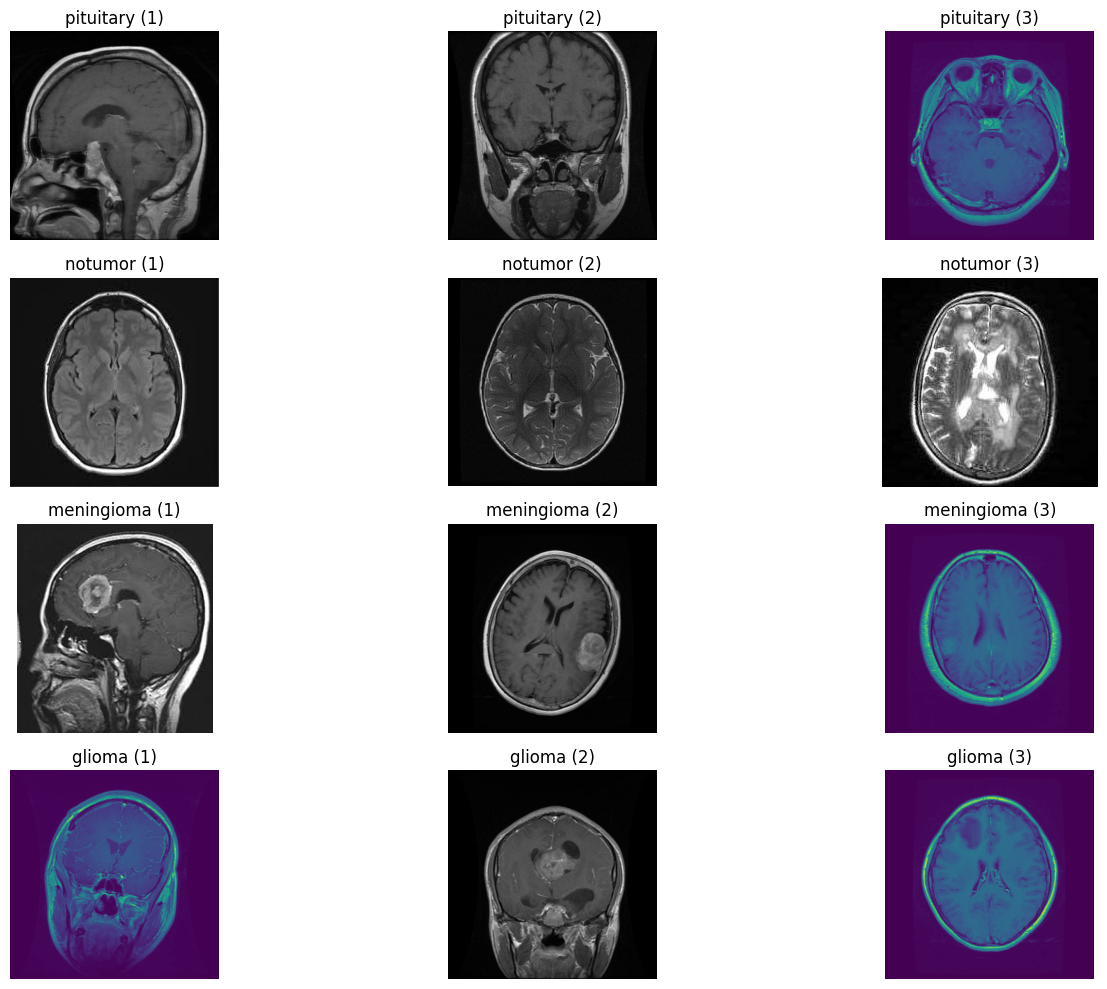

In [11]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# Get unique labels
labels = dataset_df['label'].unique()

# Set up the plot for visualizing sample images
plt.figure(figsize=(15, 10))

for i, label in enumerate(labels):
    # Get filepaths for the current label
    label_filepaths = dataset_df[dataset_df['label'] == label]['filepath'].tolist()

    # Select a random sample of images (e.g., 3 images per class)
    sample_images_paths = random.sample(label_filepaths, min(3, len(label_filepaths)))

    for j, img_path in enumerate(sample_images_paths):
        plt.subplot(len(labels), 3, i * 3 + j + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"{label} ({j+1})")
        plt.axis('off')

plt.tight_layout()
plt.show()

### Inspecting Image Dimensions and Color Channels

Image dimensions and color channels are critical attributes that can influence model design and preprocessing. Let's analyze these characteristics across our dataset to identify any inconsistencies or requirements for resizing and normalization.


--- Image Dimensions Analysis ---
Min Width: 173, Max Width: 1280, Mean Width: 455.96
Min Height: 168, Max Height: 872, Mean Height: 455.71
Unique Widths: [ 173  177  192  194  200  201  206  208  211  212  213  214  215  216
  218  224  225  227  228  230  232  235  236  249  256  267  275  291
  300  305  306  341  354  359  380  393  400  405  420  428  440  441
  442  455  472  474  495  504  512  526  534  540  550  562  572  626
  630  642  645  680  785  850  900 1280]
Unique Heights: [168 192 197 201 213 214 216 217 221 222 225 227 229 231 234 235 236 237
 238 239 242 244 250 251 252 256 259 262 280 282 293 300 301 325 328 340
 361 365 372 398 400 417 439 442 443 449 474 484 500 512 530 536 537 540
 568 575 583 592 619 630 664 674 680 720 741 848 872]

--- Color Channels Analysis ---
Unique Number of Channels: [1 3]
Most common channel count: 3 (appears 282 times)


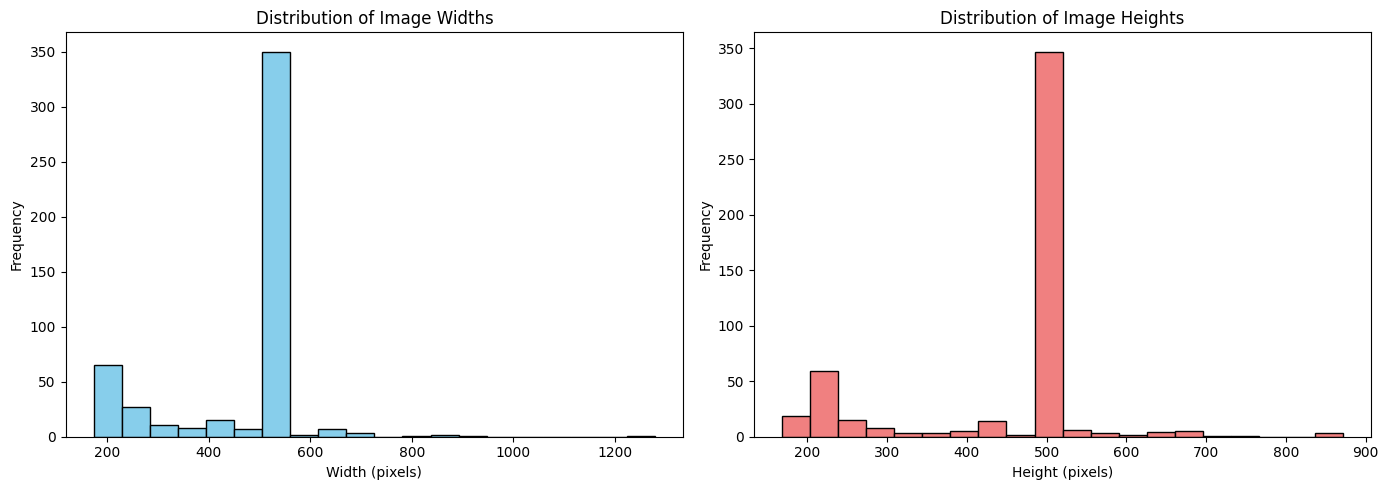

In [13]:
from PIL import Image
import numpy as np

# Initialize lists to store image properties
widths = []
heights = []
channels = []

# Iterate through a sample of filepaths to get properties (to save time, we can sample a subset)
# For a full analysis, iterate through dataset_df['filepath']
# Taking a smaller sample for quick EDA
sample_filepaths = dataset_df['filepath'].sample(n=500, random_state=42).tolist()

for img_path in sample_filepaths:
    try:
        with Image.open(img_path) as img:
            widths.append(img.width)
            heights.append(img.height)

            # Check number of channels
            if img.mode == 'RGB':
                channels.append(3)
            elif img.mode == 'L': # Grayscale
                channels.append(1)
            else:
                channels.append(len(img.getbands())) # Handle other modes
    except Exception as e:
        print(f"Error opening image {img_path}: {e}")

# Convert to numpy arrays for analysis
widths = np.array(widths)
heights = np.array(heights)
channels = np.array(channels)

print("\n--- Image Dimensions Analysis ---")
print(f"Min Width: {widths.min()}, Max Width: {widths.max()}, Mean Width: {widths.mean():.2f}")
print(f"Min Height: {heights.min()}, Max Height: {heights.max()}, Mean Height: {heights.mean():.2f}")
print(f"Unique Widths: {np.unique(widths)}")
print(f"Unique Heights: {np.unique(heights)}")

print("\n--- Color Channels Analysis ---")
print(f"Unique Number of Channels: {np.unique(channels)}")
print(f"Most common channel count: {np.bincount(channels).argmax()} (appears {np.bincount(channels).max()} times)")

# Plotting distribution of dimensions (optional, but good for visual EDA)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Image Widths')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')

axes[1].hist(heights, bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Image Heights')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Checking for Corrupted Images

Before proceeding with model training, it's crucial to identify and handle any corrupted or unreadable image files in the dataset. This step ensures data integrity and prevents errors during data loading and preprocessing.

In [15]:
from PIL import Image
import os

corrupted_images = []

print("Checking for corrupted images across the dataset...")

# Iterate through all image filepaths in the combined dataset_df
for index, row in dataset_df.iterrows():
    img_path = row['filepath']
    try:
        # Attempt to open and verify the image
        with Image.open(img_path) as img:
            img.verify() # Verify if the file is a valid image
    except Exception as e:
        corrupted_images.append({'filepath': img_path, 'error': str(e)})
        # Optional: print progress for large datasets
        # if len(corrupted_images) % 10 == 0:
        #     print(f"Found {len(corrupted_images)} corrupted images so far...")

if corrupted_images:
    print(f"\nFound {len(corrupted_images)} corrupted or unreadable images:")
    for item in corrupted_images:
        print(f"  - {item['filepath']}: {item['error']}")
    print("It is recommended to remove these files or handle them appropriately before proceeding.")
    # Optionally, create a DataFrame for corrupted images
    corrupted_df = pd.DataFrame(corrupted_images)
else:
    print("\nNo corrupted or unreadable images found. The dataset appears to be clean.")

Checking for corrupted images across the dataset...

No corrupted or unreadable images found. The dataset appears to be clean.


### Image Preprocessing Considerations

Given the variability in image dimensions and color channels identified earlier, preprocessing is a vital step for preparing our dataset for machine learning models. Common preprocessing steps include:

1.  **Resizing:** Standardizing all images to a uniform width and height.
2.  **Normalization:** Scaling pixel values (e.g., to a range of 0-1 or -1 to 1).
3.  **Channel Conversion:** Ensuring all images have a consistent number of channels (e.g., converting all to RGB or grayscale).

Let's demonstrate a basic preprocessing step by resizing a sample of images and converting them to RGB format. This will illustrate how we can handle dimension and channel inconsistencies.

Processing a sample of 5 images to 224x224 pixels and RGB format...
Processing complete. Displaying original vs. processed images.


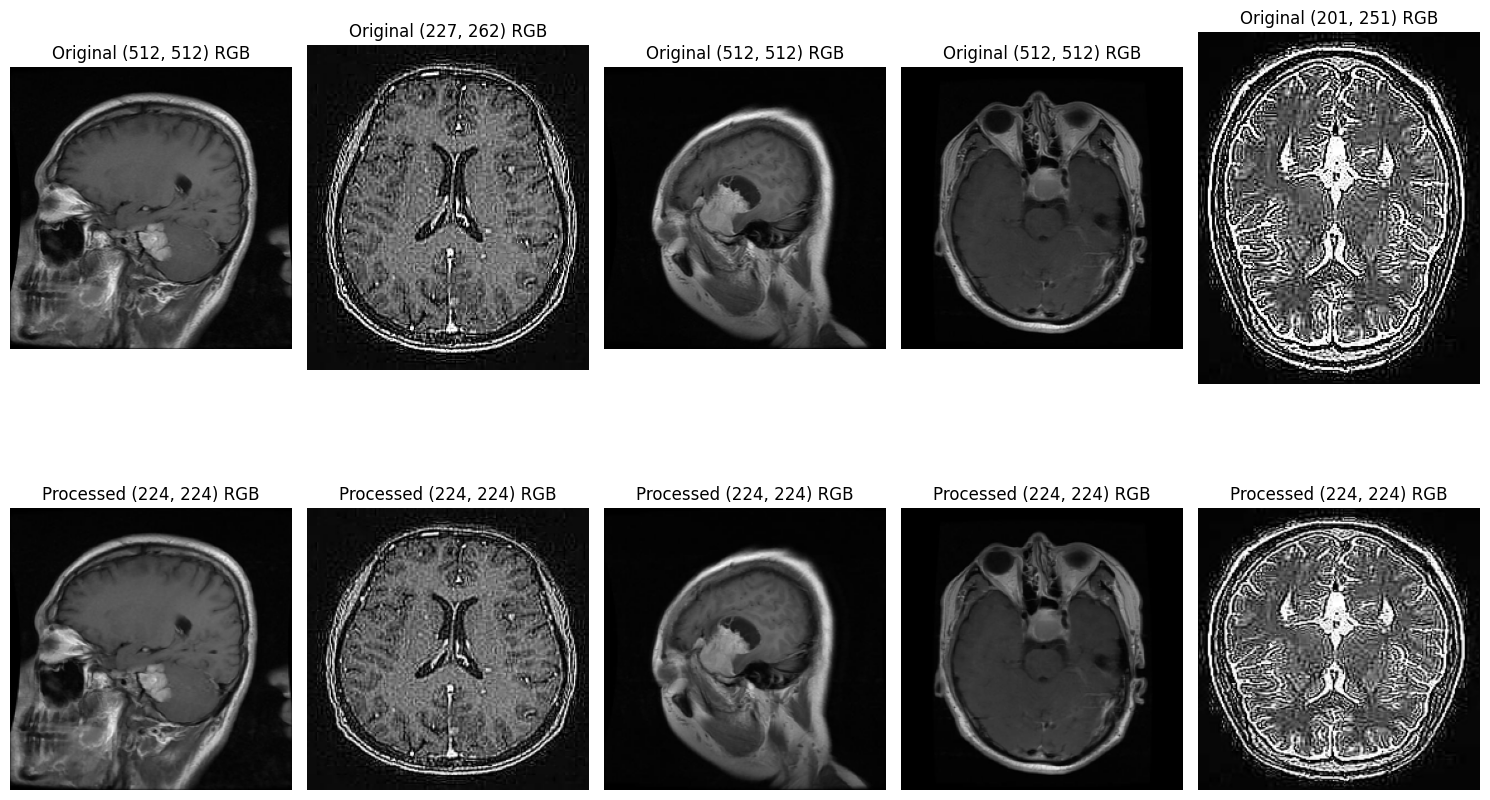


Example: Original image 1 was (512, 512) with mode RGB
Example: Processed image 1 is now (224, 224) with mode RGB


In [16]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define target dimensions and channels
target_size = (224, 224) # Common size for many deep learning models
target_channels = 'RGB' # Convert all to RGB

processed_images_sample = []
original_images_sample = []

print(f"Processing a sample of 5 images to {target_size[0]}x{target_size[1]} pixels and {target_channels} format...")

# Select a small random sample of images for demonstration
sample_paths = dataset_df['filepath'].sample(n=5, random_state=42).tolist()

for img_path in sample_paths:
    try:
        with Image.open(img_path) as img:
            original_images_sample.append(img) # Store original for comparison

            # Convert to target_channels (e.g., RGB) if not already
            if img.mode != target_channels:
                img = img.convert(target_channels)

            # Resize image
            img_resized = img.resize(target_size)
            processed_images_sample.append(img_resized)

    except Exception as e:
        print(f"Error processing image {img_path}: {e}")

print("Processing complete. Displaying original vs. processed images.")

# Display original and processed images side-by-side
plt.figure(figsize=(15, 10))
for i in range(len(sample_paths)):
    # Original Image
    plt.subplot(2, len(sample_paths), i + 1)
    plt.imshow(original_images_sample[i])
    plt.title(f"Original {original_images_sample[i].size} {original_images_sample[i].mode}")
    plt.axis('off')

    # Processed Image
    plt.subplot(2, len(sample_paths), len(sample_paths) + i + 1)
    plt.imshow(processed_images_sample[i])
    plt.title(f"Processed {processed_images_sample[i].size} {processed_images_sample[i].mode}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nExample: Original image 1 was {original_images_sample[0].size} with mode {original_images_sample[0].mode}")
print(f"Example: Processed image 1 is now {processed_images_sample[0].size} with mode {processed_images_sample[0].mode}")

### Data Augmentation Considerations

Data augmentation is a powerful technique in computer vision to increase the diversity of the training data and prevent overfitting. By applying random transformations to images, we can generate new, realistic training examples without collecting additional data.

Common augmentation techniques include:
-   **Random rotations**
-   **Horizontal/vertical flips**
-   **Zooming**
-   **Shifting (width/height)**
-   **Brightness adjustments**

Let's demonstrate a few common augmentation techniques using a sample image to visualize their effects.

Demonstrating data augmentation on image: /kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_225.jpg


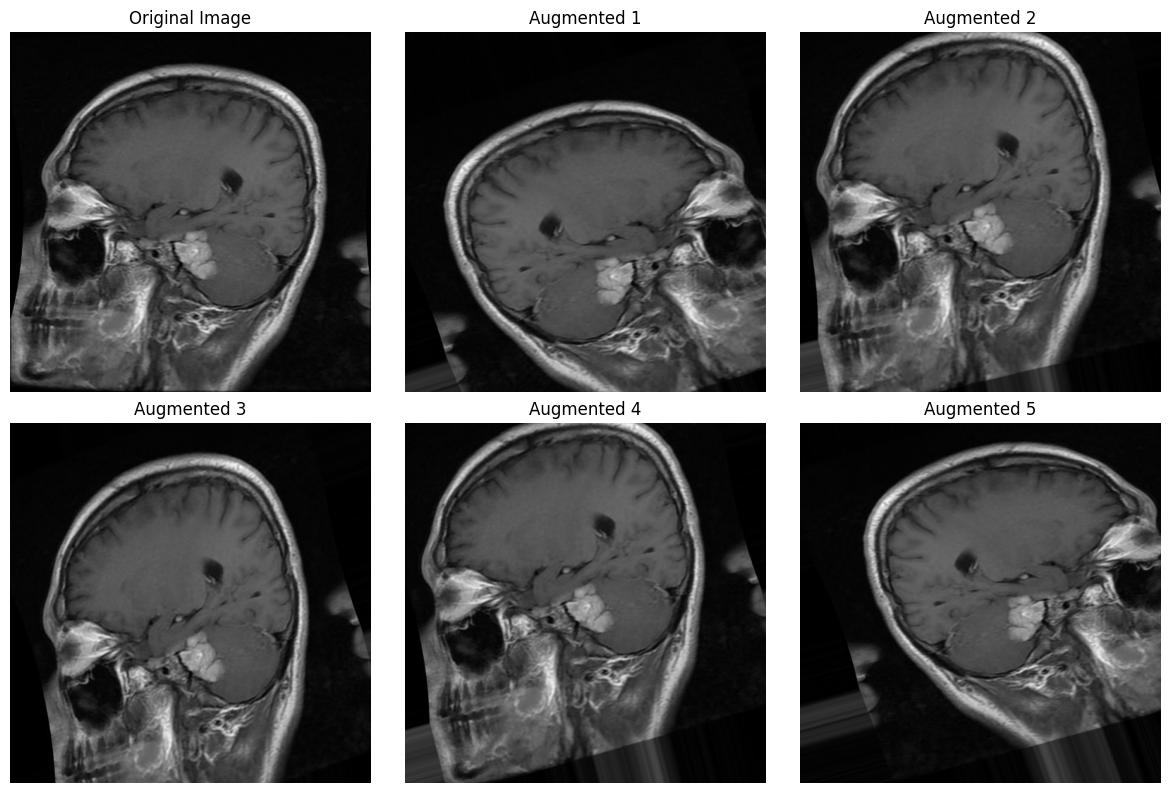

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Select a single image for demonstration
sample_image_path = dataset_df['filepath'].sample(n=1, random_state=42).iloc[0]
original_image = Image.open(sample_image_path).convert('RGB')
original_image_np = np.array(original_image)

print(f"Demonstrating data augmentation on image: {sample_image_path}")

# ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Reshape the image to (1, height, width, channels) for datagen flow
image_for_datagen = np.expand_dims(original_image_np, 0)

# Generate augmented images
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(original_image_np)
plt.title("Original Image")
plt.axis('off')

i = 2
for batch in datagen.flow(image_for_datagen, batch_size=1):
    plt.subplot(2, 3, i)
    plt.imshow(batch[0].astype('uint8'))
    plt.title(f"Augmented {i-1}")
    plt.axis('off')
    i += 1
    if i > 6:
        break # show 5 augmented images

plt.tight_layout()
plt.show()